### Research and Report Hierarchical Agent Teams System

A supervisor agent's work is to route between different work nodes. But when job becomes complex or there is a large number of workers it becomes difficult for the supervisor to effectively call the correct worker node.

For such cases hierarchically distributed architecture works best. We can build this by composing different sub-graphs and creating a top-level supervisor along with mid-level supervisors.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool

llm = ChatOpenAI(model='o3-mini')

USER_AGENT environment variable not set, consider setting it to identify your requests.


## Building Research Team Tools

In [ ]:
tavily_tool = TavilySearchResults(max_results = 5)

In [10]:
from typing import Annotated, TypedDict, Literal, Any
from langchain_core.language_models.chat_models import BaseChatModel
from langgraph.graph import MessagesState, MessageGraph, START,END, StateGraph
from langgraph.types import Command

class State(MessagesState):
    next: str

# def make_research_supervisor(llm:BaseChatModel, members: list[str]) -> str:
#     print('<-- Research Supervisor -->')
    
#     node_members = members + ['FINISH']
#     print(node_members)

In [80]:
members = ['general_researcher','finance_researcher','medical_researcher','FINISH']
system_prompt = f"""
        You are a supervisor managing a task delegation system with the following workers: {members}.

        Your job is to decide which worker should act next based on the user’s input.

        Guidelines:
        - Carefully read the user’s message.
        - If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.
        - If the message is related to finance return finance_researcher.
        - If the message is related to medical or medicine science return medical_researcher.
        - If the message is realted to general research return general_researcher
        - Once all the tasks are completed respond with FINISH
        - Do **not** invent tasks or assign actions unless the message clearly demands it.

        Each worker will return results after completing their task.
        Once all necessary tasks are completed, end the flow by responding with `FINISH`.

        Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`."""
        
    
class Router(TypedDict):
    next: Literal['general_researcher','finance_researcher','medical_researcher','FINISH']
        
    
def research_supervisor(state:State) -> Command[Literal['general_researcher','finance_researcher','medical_researcher','__end__']]:
    print('<-- Researcher Supervisor -->')
    
    messages = [{'role':'system','content':system_prompt}] + state['messages']
    
    response = llm.with_structured_output(Router).invoke(messages)
    
    goto = response['next']
    
    print("*********Below is my GOTO*****************")
    
    print(goto)
    
    if goto =='FINISH':
        goto=END
    
    return Command(goto=goto, update={'next':goto})



##### Research Agents

In [38]:
from langchain import hub
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage, AIMessage


def general_research(state:State) -> Command[Literal['supervisor']]:
    print('<-- General Researcher -->')
    
    prompt = 'You are a researcher who researches on general topics only.Do a through research on the query provided'
    tavily_agent = create_react_agent(llm, tools= [tavily_tool],prompt=prompt)
    
    result = tavily_agent.invoke(state)
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=result['messages'][-1].content, name='general_researcher')]}
    )

In [82]:
from langchain_community.retrievers import PubMedRetriever
from langchain.tools.retriever import create_retriever_tool

def medical_research(state:State) -> Command[Literal['supervisor']]:
    print('<-- Medical Researcher -->')
    
    prompt = 'You are a researcher who researches on Medical topics only.Do a through research on the query provided'
    
    retriever = PubMedRetriever()

    medical_retriever_tool = create_retriever_tool(
        retriever=retriever,
        name = 'medical_researcher',
        description='''
        You are a expert in medical research. 
        Search and return information about user query related to medicine, medical emergencies and medications to take.
        '''
    )
    medical_agent = create_react_agent(llm, tools= [medical_retriever_tool,tavily_tool],prompt=prompt)
    
    result = medical_agent.invoke(state)
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=result['messages'][-1].content, name='medical_researcher')]}
    )

In [83]:
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool
from langchain_core.prompts import PromptTemplate
import yfinance as yf

yfinance =YahooFinanceNewsTool()

@tool
def get_stock_price(ticker:str) -> str:
    '''
    Fetch the last closed price of the given stock ticker
    
    Args:
        ticker (str) : Stock ticker symbol (e.g, 'NVDA','MFST')
    '''
    dat = yf.Ticker(ticker)
    previous_close_price = dat.info.get('previousClose')
    previous_open_price = dat.info.get('open')
    day_high = dat.info.get('dayHigh')
    day_low = dat.info.get('dayLow')
    if previous_close_price is None:
        return f'Could not fetch price detail for {ticker}'
    return f'Last closing price for {ticker} was ${previous_close_price} with day open price ${previous_open_price} and day highest ${day_high} and day lowest ${day_low}.'
    

def finance_research(state:State) -> Command[Literal['supervisor']]:
    print('<-- Finance Researcher -->')
    
    prompt = "You are a researcher who is an expert on Financial Topics only. Do a through research on the query provided."
            
    yfinance_agent = create_react_agent(llm,tools=[yfinance,get_stock_price], prompt=prompt)
    print(state)
    
    response = yfinance_agent.invoke(state)
    
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=response['messages'][-1].content, name='finance_researcher')]}
    )
    
#research_supervisor_node = make_research_supervisor(llm,['general_researcher','finance_researcher'])

In [84]:
## Building Research Graph

research_builder = StateGraph(State)
research_builder.add_node('supervisor', research_supervisor)
research_builder.add_node('general_researcher', general_research)
research_builder.add_node('finance_researcher',finance_research)
research_builder.add_node('medical_researcher', medical_research)

## Logic
research_builder.add_edge(START,'supervisor')

## Compile
research_app = research_builder.compile()

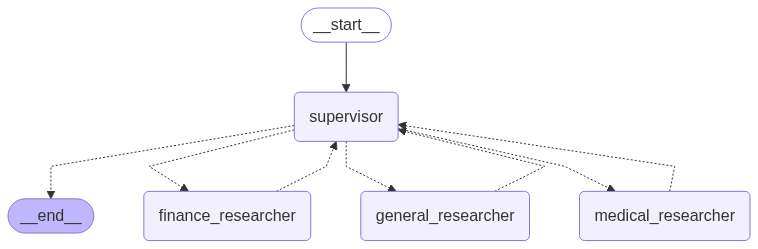

In [85]:
research_app

In [71]:
message = [HumanMessage(content="How did Nvidia stock performed today in comparision to Microsoft")]
response = research_app.invoke({'messages':message})
print(response)

<-- Researcher Supervisor -->
*********Below is my GOTO*****************
finance_researcher
<-- Finance Researcher -->
{'messages': [HumanMessage(content='How did Nvidia stock performed today in comparision to Microsoft', additional_kwargs={}, response_metadata={}, id='1973e628-e118-4df6-b505-e994e8edc912')], 'next': 'finance_researcher'}
<-- Researcher Supervisor -->
*********Below is my GOTO*****************
FINISH
{'messages': [HumanMessage(content='How did Nvidia stock performed today in comparision to Microsoft', additional_kwargs={}, response_metadata={}, id='1973e628-e118-4df6-b505-e994e8edc912'), HumanMessage(content='Based on the data, here’s a comparison of how the two stocks performed today:\n\n1. Nvidia (NVDA):\n   • Open Price: $158.35\n   • Closing Price: $157.25\n   • Change: A decrease of $1.10, which roughly translates to a decline of about 0.7% from its opening price.\n\n2. Microsoft (MSFT):\n   • Open Price: $493.495\n   • Closing Price: $491.09\n   • Change: A decre

In [72]:
response['messages'][-1].pretty_print()

================================ Human Message =================================
Name: finance_researcher

Based on the data, here’s a comparison of how the two stocks performed today:

1. Nvidia (NVDA):
   • Open Price: $158.35
   • Closing Price: $157.25
   • Change: A decrease of $1.10, which roughly translates to a decline of about 0.7% from its opening price.

2. Microsoft (MSFT):
   • Open Price: $493.495
   • Closing Price: $491.09
   • Change: A decrease of $2.405, which is roughly a decline of 0.49% from its opening price.

In relative terms, although both stocks experienced declines during the day, Nvidia’s stock fell by a slightly larger percentage (around 0.7%) compared to Microsoft’s (approximately 0.5%). This indicates that on a percentage basis, Nvidia underperformed Microsoft by about 0.2 percentage points today.


In [86]:
message = [HumanMessage(content="I am having stomach pain. What medicine can I take?")]
response = research_app.invoke({'messages':message})
print(response)

<-- Researcher Supervisor -->
*********Below is my GOTO*****************
medical_researcher
<-- Medical Researcher -->
<-- Researcher Supervisor -->
*********Below is my GOTO*****************
FINISH
{'messages': [HumanMessage(content='I am having stomach pain. What medicine can I take?', additional_kwargs={}, response_metadata={}, id='8ccde724-afc6-4a5a-b146-9c117d361816'), HumanMessage(content="I'm not a doctor, but here’s a summary of common over-the-counter options and factors to consider when dealing with stomach pain. However, because “stomach pain” can result from a wide range of causes—from indigestion or gas to more serious conditions—it's important to consider the nature of your pain (e.g., sharp versus cramping, accompanied by other symptoms) and consult a healthcare provider if the pain is severe, persistent, or accompanied by symptoms like fever, vomiting, or bleeding.\n\n1. Indigestion or Heartburn:  \n   • Antacids (such as Tums, Rolaids, or Maalox) can neutralize stomach

In [87]:
response['messages'][-1].pretty_print()

================================ Human Message =================================
Name: medical_researcher

I'm not a doctor, but here’s a summary of common over-the-counter options and factors to consider when dealing with stomach pain. However, because “stomach pain” can result from a wide range of causes—from indigestion or gas to more serious conditions—it's important to consider the nature of your pain (e.g., sharp versus cramping, accompanied by other symptoms) and consult a healthcare provider if the pain is severe, persistent, or accompanied by symptoms like fever, vomiting, or bleeding.

1. Indigestion or Heartburn:  
   • Antacids (such as Tums, Rolaids, or Maalox) can neutralize stomach acid and may relieve pain related to acid reflux or indigestion.  
   • H2 blockers (like ranitidine or famotidine) or proton pump inhibitors (such as omeprazole) reduce acid production. These are typically used if you experience frequent heartburn but are generally taken as short-term treatme

#### Document Writing Team

In [ ]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional,List, Annotated
from langchain_experimental.utilities import PythonREPL

dir_name = 'outputfiles'
os.makedirs(dir_name,exist_ok=True)

@tool
def create_outine(
    points: Annotated[List[str], "List of main points and sections."],
    file_name: Annotated[str, "File name to save the outline"]
) -> Annotated[str,"Path of saved outline file"]:
    """ Create and saved the outline of the document"""
    
    full_path = os.path.join(dir_name,file_name)
    with open(full_path,'w') as file:
        for i, point in enumerate(points):
            file.write(f"{i+1}.{point}\n")
    return f"Outline saved to {full_path}"

@tool
def read_document(
    file_name: Annotated[str, "File name to read the document from"],
    start: Annotated[Optional[int], 'The start line. Default is 0']=None,
    end: Annotated[Optional[int],' The end line. Default is None'] = None
) -> str:
    '''Read the specific document'''
    
    full_path = os.path.join(dir_name, file_name)
    with open(full_path,'r') as file:
        lines = file.readlines()
    if start is None:
        start=0
    return "\n".join(lines[start:end])

@tool
def write_document(
    content: Annotated[List[str],"Text content to be written into the document"],
    file_name: Annotated[str,"File name to save the document"]
) -> Annotated[str,"Path of the saved document"]:
    '''Create and save the text document'''
    
    file_path = os.path.join(dir_name,file_name)
    with open(file_path,'w') as file:
        file.write(content)
    return f"Document saved to {file_path}"

@tool
def edit_document(
    file_name: Annotated[str,"File name of the document to be edited"],
    inserts: Annotated[Dict[int,str],"Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line"]
) ->Annotated[str,"Path of saved outline file"]:
    '''Edit the document by inserting the text and charts at specific numbers'''
    full_path = os.path.join(dir_name, file_name)
    with open(full_path,'r') as file:
        lines = file.readlines()
        
    sorted_inserts = sorted(inserts.items())
    
    for line_number, text in sorted_inserts:
        if 1<=line_number<=len(line_number)+1:
            lines.insert(line_number-1,text+"\n")
        else:
            return f"Error: Line number {line_number} is out of range"
        
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute and generate your chart"]):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        repl = PythonREPL()
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

@tool
def summarize_content(
    content: Annotated[str,"The content provided by researcher team to be summarized"]
) -> str:
    '''Summarize the content provided to you in a proper format'''
    prompt = f'You are an expert summarizer, your task is to format the content provided in markdown format: \n\n {content}'
    
    response = llm.invoke(content)
    return f"Summarized Content: \n {response}"


In [ ]:
def doc_writing_node(state:State) -> Command[Literal['supervisor']]:
    print('<-- Document Writing Agent -->')
    
    prompt = ('You can read, write and edit documents based on summarizer outline.'
              "Don't ask follow up questions")
    
    writing_agent = create_react_agent(
        llm,
        tools=[write_document,read_document,edit_document],
        prompt=prompt
    )
    
    response = writing_agent.invoke(state)
    
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=response['messages'][-1].content, name='doc_writer')]}
    )
    

def summarizing_node(state:State) -> Command[Literal['supervisor']]:
    print('<-- Summarizer Agent -->')
    
    prompt = ('You can summarize the content provided by researcher team, can read documents and create outlines for the document writer'
              "Don't ask follow up questions")
    
    summerizer_agent = create_react_agent(
        llm,
        tools=[summarize_content,read_document,create_outine]
    )


'Outline saved to outputfiles\\stomach.docx'